# WolBanking77 : Classification d'intentions bancaires en Wolof

Ce notebook unique realise le projet complet : exploration des donnees, baseline Machine Learning, entrainement XLM-RoBERTa, evaluation et comparaison.

## Architecture d'execution

- **GitHub** fournit le projet, le code et les CSV. Colab clone le depot a chaque execution dans `/content/WolBanking77`.
- **Google Drive** conserve les sorties persistantes : meilleur checkpoint, rapports CSV/JSON et graphiques.
- **Le test officiel reste reserve a l'evaluation finale**. Le meilleur checkpoint Transformer est choisi avec 10 % du train, separes de maniere stratifiee.

Avant de lancer le notebook, placez les donnees dans votre depot GitHub et renseignez son URL HTTPS dans la cellule suivante. Pour une explication complete, consultez `docs/GUIDE_COLAB.md` dans le depot.

## 1. Importer le projet depuis GitHub et connecter Google Drive

In [1]:
from google.colab import drive
from pathlib import Path

# Clone le projet avec les donnée depuis mon GitHub.
GITHUB_REPOSITORY_URL = 'https://github.com/alimar440/Projet-WolBanking77.git'
REPOSITORY_DIR = Path('/content/WolBanking77')
DRIVE_OUTPUT_DIR = Path('/content/drive/MyDrive/WolBanking77_runs')

drive.mount('/content/drive')
if not REPOSITORY_DIR.exists():
    !git clone $GITHUB_REPOSITORY_URL $REPOSITORY_DIR
else:
    %cd $REPOSITORY_DIR
    !git pull
%cd $REPOSITORY_DIR

assert (REPOSITORY_DIR / 'data').exists(), 'Le depot GitHub doit contenir le dossier data.'
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Projet GitHub :', REPOSITORY_DIR)
print('Sorties Drive :', DRIVE_OUTPUT_DIR)

Mounted at /content/drive
Cloning into '/content/WolBanking77'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 30 (delta 4), reused 29 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 1.59 MiB | 4.27 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/WolBanking77
Projet GitHub : /content/WolBanking77
Sorties Drive : /content/drive/MyDrive/WolBanking77_runs


## 2. Installer les bibliotheques et configurer l'experience

Choisissez `5k_split` pour le jeu de 4 000 / 1 000 exemples ou `full` pour le jeu complet. Activez un GPU Colab pour accelerer le Transformer.

In [2]:
!pip -q install transformers sentencepiece joblib

import json
import random
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DATASET_NAME = '5k_split'
TEXT_COLUMN, LABEL_COLUMN = 'input_wo', 'label'

# Recommandation 4 : xlm-roberta-base est un modele generaliste ou le wolof est
# tres peu represente au pre-entrainement. Un modele couvrant les langues
# africaines bas-ressource converge generalement plus vite sur ce type de tache.
# Laissez la valeur par defaut si vous voulez rester comparable au premier essai,
# ou testez l'alternative pour voir si le macro-F1 s'ameliore plus vite.
MODEL_NAME = 'xlm-roberta-base'
# MODEL_NAME = 'Davlan/afro-xlmr-base'  # alternative bas-ressource africaine a tester

# Recommandation 3 : MAX_LENGTH reduit. Les questions bancaires en wolof sont
# courtes ; 128 sous-tokens ajoutait surtout du padding inutile qui ralentissait
# chaque epoque sans apporter d'information. Verifiez la longueur reelle des
# textes dans explore_data() et ajustez si besoin.
MAX_LENGTH = 64

BATCH_SIZE = 16 if torch.cuda.is_available() else 4

# Recommandation 1 : plus d'epoques. Le premier essai s'arretait a EPOCHS=6 alors
# que le F1 de validation progressait encore (pas de plateau) : le modele etait
# sous-entraine, pas casse. On laisse desormais davantage de marge et on
# s'appuie sur le early stopping (PATIENCE) pour arreter au bon moment.
LEARNING_RATE, EPOCHS, PATIENCE = 2e-5, 20, 3

# Recommandation 2 : learning rate differencie. La tete de classification (77
# classes) est initialisee aleatoirement alors que le corps XLM-R est pre-entraine :
# lui appliquer un LR plus eleve accelere son apprentissage sans deregler le
# corps du modele.
HEAD_LR_MULTIPLIER = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_DIR = REPOSITORY_DIR / 'data' / DATASET_NAME
MODELS_DIR, REPORTS_DIR = DRIVE_OUTPUT_DIR / 'models', DRIVE_OUTPUT_DIR / 'reports'
MODELS_DIR.mkdir(exist_ok=True); REPORTS_DIR.mkdir(exist_ok=True)
print('Device :', device)
print('Modele :', MODEL_NAME)
print('Donnees :', DATA_DIR)

Device : cuda
Modele : xlm-roberta-base
Donnees : /content/WolBanking77/data/5k_split


## 3. Fonction `clean_text`

Normalise les espaces sans supprimer les lettres et diacritiques utiles du wolof.

In [3]:
def clean_text(text):
    return re.sub(r'\s+', ' ', str(text).strip())

## 4. Fonction `load_data`

Charge les deux partitions CSV, controle les textes et transforme les 77 intentions en identifiants numeriques pour le Transformer.

In [4]:
def load_data():
    train = pd.read_csv(DATA_DIR / 'train' / 'train.csv', encoding='utf-8')
    test = pd.read_csv(DATA_DIR / 'test' / 'test.csv', encoding='utf-8')
    for frame in (train, test):
        frame.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN], inplace=True)
        frame['text'] = frame[TEXT_COLUMN].map(clean_text)
        frame.drop(frame.index[frame['text'].eq('')], inplace=True)
        frame.drop_duplicates(subset=['text'], inplace=True)
        frame.reset_index(drop=True, inplace=True)
    encoder = LabelEncoder()
    train['label_id'] = encoder.fit_transform(train[LABEL_COLUMN])
    test['label_id'] = encoder.transform(test[LABEL_COLUMN])
    return train, test, encoder

train_df, test_df, label_encoder = load_data()
print(f'Train : {len(train_df)} | Test : {len(test_df)} | Intentions : {len(label_encoder.classes_)}')
display(train_df[['input_wo', 'label']].head())

Train : 3998 | Test : 1000 | Intentions : 77


,input_wo,label
0,Jotuma xaalis waaye terewul am na lu nu ma dagg.,wrong amount of cash received
1,"Salaamaalekum, maa ngi doog a yëg ne jël nañu ...",cash withdrawal not recognised
2,Lu tax sama peyooru kàrt jàllagul ?,pending card payment
3,ndax mën naa jëfandikoo sarse ak Apple Pay?,apple pay or google pay
4,Lu tax ma war a fey ay fere su ma jëfandikoo s...,card payment fee charged


## 5. Fonction `explore_data`

Produit un controle de qualite et la distribution des intentions, utiles pour le rapport de projet.

,train,test
Exemples,3998,1000
Intentions,77,77
Doublons,0,0


,Exemples par intention
Minimum,11.000000
Mediane,52.000000
Maximum,84.000000
Ecart-type,14.285405


2 intentions ont moins de la moitie de la mediane d'exemples (a surveiller) :
label
contactless not working     11
virtual card not working    17
Longueur des textes (en mots) : mediane=11, 95e percentile=31, max=81


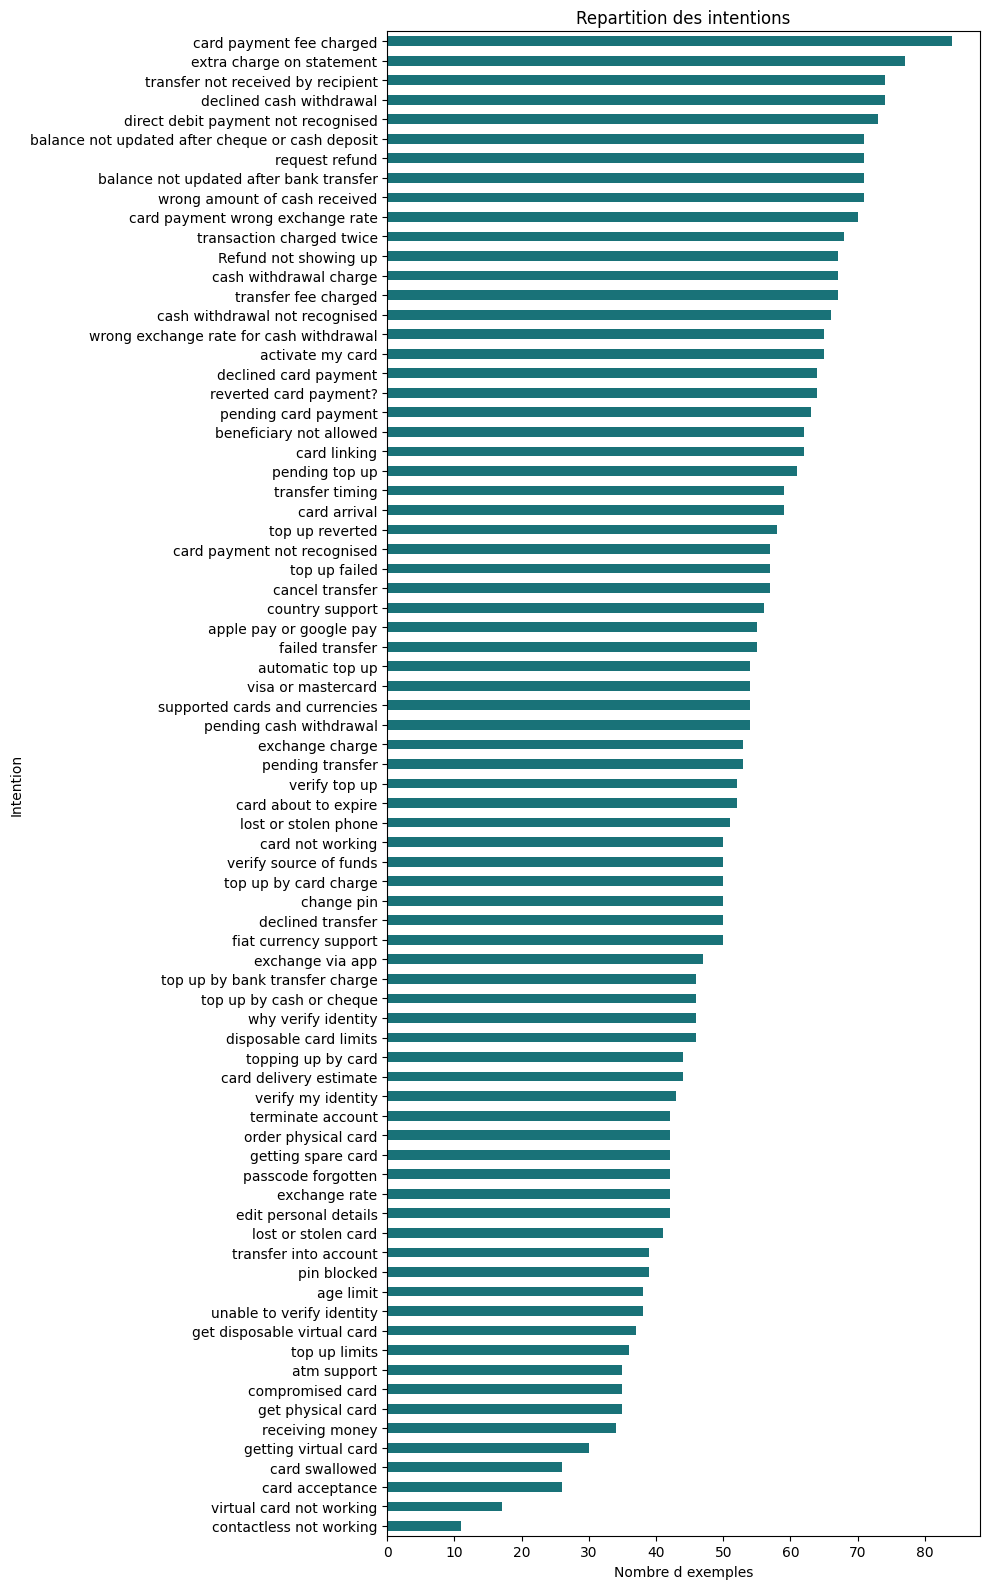

In [5]:
def explore_data(train, test):
    summary = pd.DataFrame({'train': [len(train), train['label'].nunique(), train['text'].duplicated().sum()], 'test': [len(test), test['label'].nunique(), test['text'].duplicated().sum()]}, index=['Exemples', 'Intentions', 'Doublons'])
    display(summary)

    # Recommandation 5 : equilibre des classes. Avec 77 intentions sur ~4000
    # exemples train, la moyenne est d'environ 52 exemples/classe mais la
    # repartition reelle peut etre tres inegale (certaines intentions sur- ou
    # sous-representees), ce qui penalise surtout le macro-F1.
    counts = train['label'].value_counts().sort_values()
    balance = pd.DataFrame({
        'Exemples par intention': [counts.min(), counts.median(), counts.max(), counts.std()],
    }, index=['Minimum', 'Mediane', 'Maximum', 'Ecart-type'])
    display(balance)
    rares = counts[counts < counts.median() / 2]
    if len(rares):
        print(f"{len(rares)} intentions ont moins de la moitie de la mediane d'exemples (a surveiller) :")
        print(rares.to_string())

    # Recommandation 3 : longueur des textes, pour valider/ajuster MAX_LENGTH.
    lengths = train['text'].str.split().map(len)
    print(f"Longueur des textes (en mots) : mediane={lengths.median():.0f}, 95e percentile={lengths.quantile(0.95):.0f}, max={lengths.max()}")

    fig, axis = plt.subplots(figsize=(10, 16))
    counts.plot.barh(ax=axis, color='#197278')
    axis.set(title='Repartition des intentions', xlabel='Nombre d exemples', ylabel='Intention')
    plt.tight_layout(); plt.savefig(REPORTS_DIR / f'{DATASET_NAME}_distribution.png', dpi=160); plt.show()

explore_data(train_df, test_df)

## 6. Fonction `build_baseline`

Construit la reference Machine Learning. Les n-grammes de caracteres aident a capturer les variations orthographiques du wolof.

In [6]:
def build_baseline():
    features = FeatureUnion([
        ('words', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True, max_features=60_000)),
        ('chars', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), sublinear_tf=True, max_features=80_000)),
    ])
    return Pipeline([('features', features), ('classifier', LinearSVC(C=1.0))])

baseline = build_baseline()
baseline.fit(train_df['text'], train_df['label'])
baseline_predictions = baseline.predict(test_df['text'])
joblib.dump(baseline, MODELS_DIR / f'baseline_{DATASET_NAME}.joblib')

['/content/drive/MyDrive/WolBanking77_runs/models/baseline_5k_split.joblib']

## 7. Fonction `evaluate_model`

Calcule les metriques, enregistre un rapport CSV/JSON et dessine la matrice de confusion dans Drive.

{'model': 'TF-IDF + LinearSVC', 'dataset': '5k_split', 'accuracy': 0.74, 'macro_f1': 0.7285507943372095}


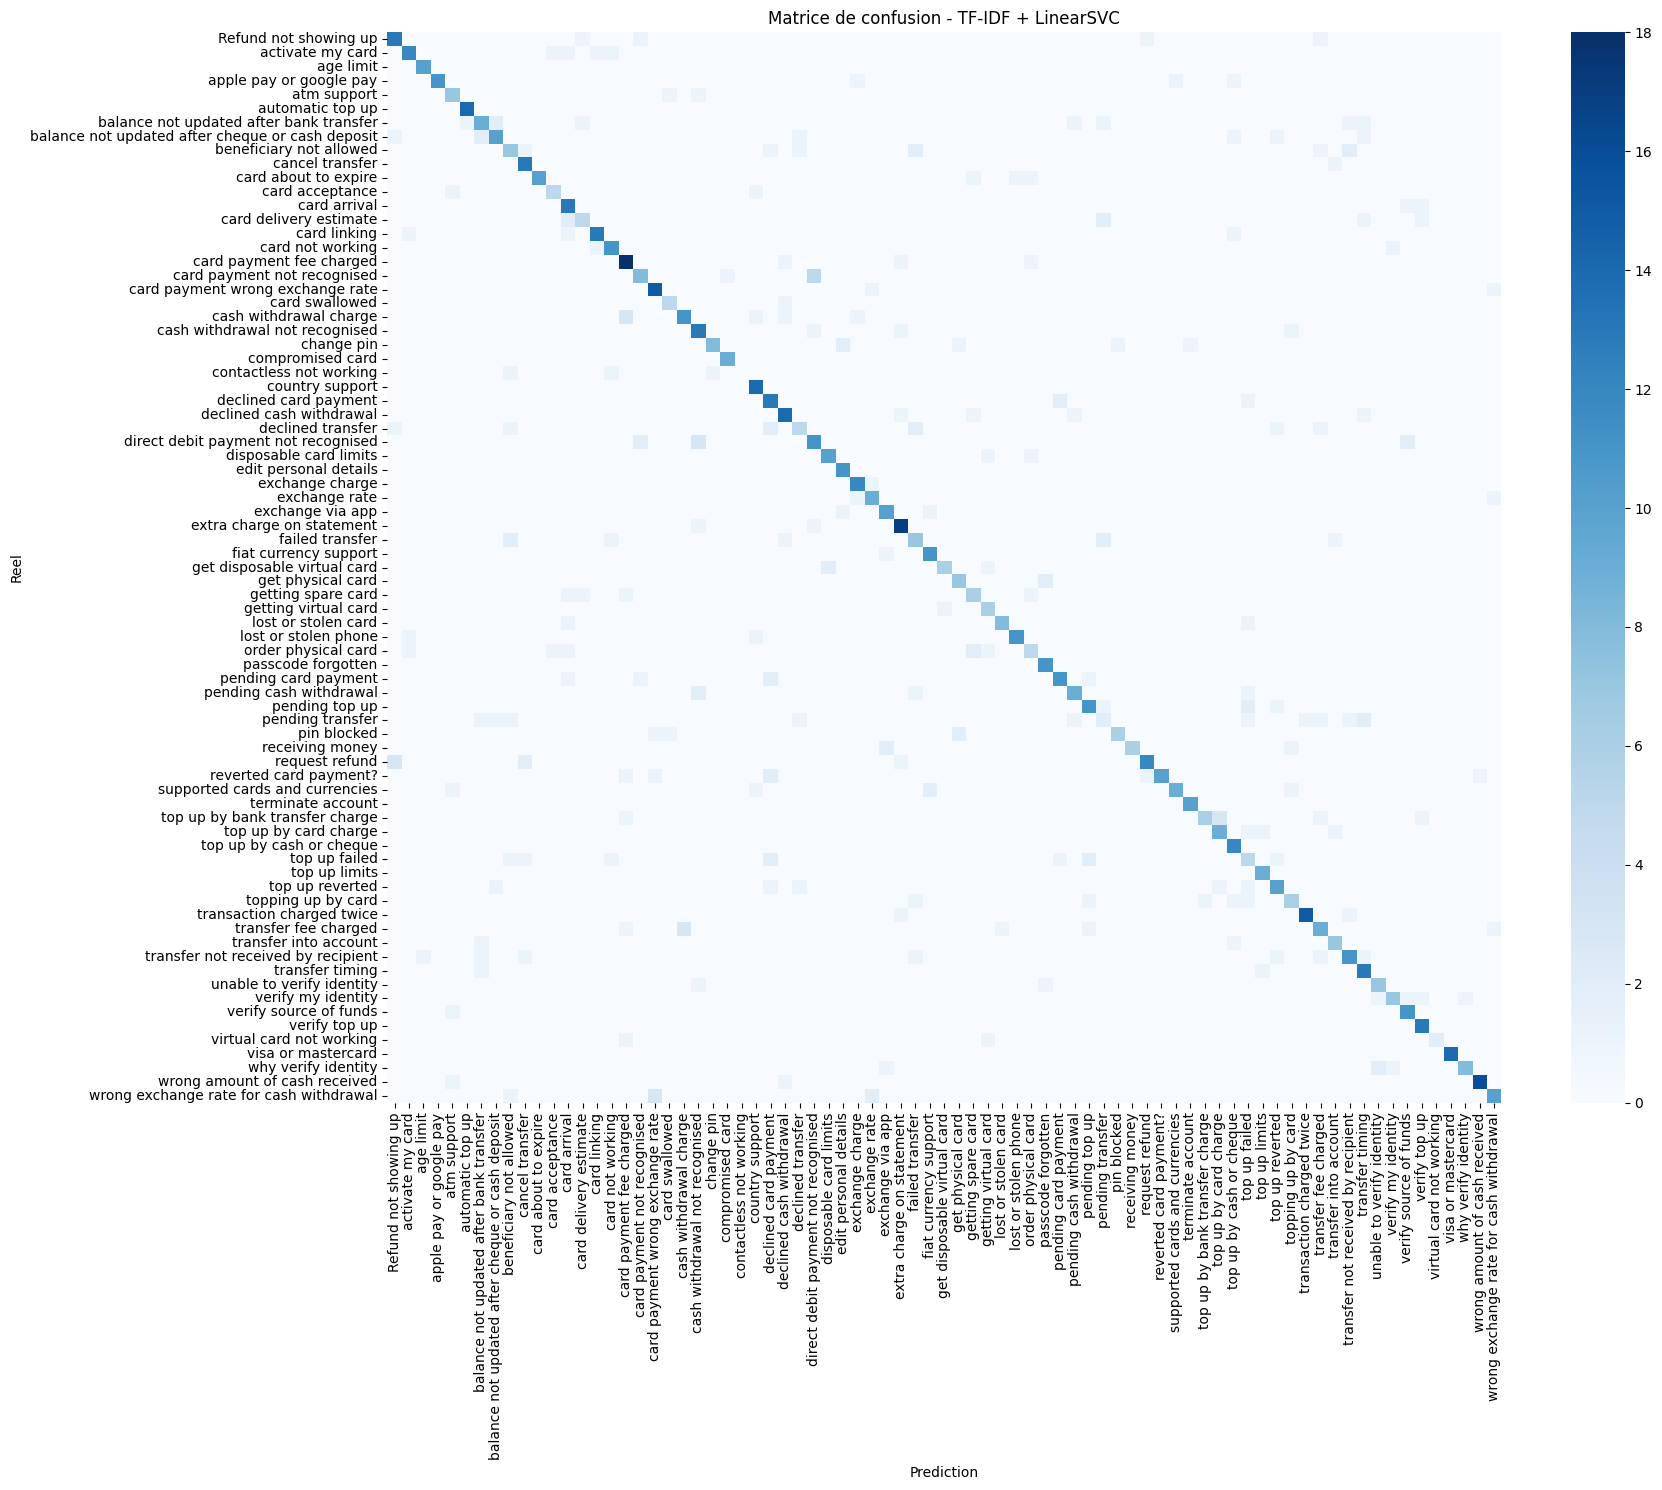

In [7]:
def evaluate_model(y_true, y_pred, model_name, prefix):
    metrics = {'model': model_name, 'dataset': DATASET_NAME, 'accuracy': float(accuracy_score(y_true, y_pred)), 'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0))}
    print(metrics)
    with open(REPORTS_DIR / f'{prefix}_metrics_{DATASET_NAME}.json', 'w', encoding='utf-8') as file: json.dump(metrics, file, ensure_ascii=False, indent=2)
    report = pd.DataFrame(classification_report(y_true, y_pred, output_dict=True, zero_division=0)).T
    report.to_csv(REPORTS_DIR / f'{prefix}_report_{DATASET_NAME}.csv', encoding='utf-8')
    matrix = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)
    fig, axis = plt.subplots(figsize=(18, 15))
    sns.heatmap(matrix, cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axis)
    axis.set(title=f'Matrice de confusion - {model_name}', xlabel='Prediction', ylabel='Reel')
    plt.tight_layout(); plt.savefig(REPORTS_DIR / f'{prefix}_confusion_{DATASET_NAME}.png', dpi=180); plt.show()
    return metrics, report

baseline_metrics, baseline_report = evaluate_model(test_df['label'], baseline_predictions, 'TF-IDF + LinearSVC', 'baseline')

## 8. Classe `IntentDataset` et fonction `create_dataloaders`

Tokenise les textes pour XLM-RoBERTa et cree un sous-ensemble de validation stratifie. Le test officiel n'est jamais utilise pour choisir le checkpoint.

In [8]:
class IntentDataset(Dataset):
    def __init__(self, frame, tokenizer):
        self.texts, self.labels = frame['text'].tolist(), frame['label_id'].tolist()
        self.tokenizer = tokenizer
    def __len__(self): return len(self.labels)
    def __getitem__(self, index):
        tokens = self.tokenizer(self.texts[index], truncation=True, max_length=MAX_LENGTH, padding='max_length', return_tensors='pt')
        return {'input_ids': tokens['input_ids'].flatten(), 'attention_mask': tokens['attention_mask'].flatten(), 'labels': torch.tensor(self.labels[index], dtype=torch.long)}

def create_dataloaders():
    train_part, val_part = train_test_split(train_df, test_size=0.10, stratify=train_df['label_id'], random_state=SEED)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    make_loader = lambda frame, shuffle=False: DataLoader(IntentDataset(frame, tokenizer), batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=2, pin_memory=torch.cuda.is_available())
    return tokenizer, make_loader(train_part, True), make_loader(val_part), make_loader(test_df)

tokenizer, train_loader, val_loader, test_loader = create_dataloaders()

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

## 9. Fonction `run_epoch`

Execute une epoque d'entrainement ou d'evaluation et retourne les predictions, loss, accuracy et macro-F1.

In [9]:
def run_epoch(model, loader, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    loss_sum, predictions, labels = 0.0, [], []
    for batch in loader:
        inputs = {key: value.to(device) for key, value in batch.items()}
        if training: optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            output = model(**inputs)
            if training:
                output.loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
        loss_sum += output.loss.item()
        predictions.extend(output.logits.argmax(dim=1).detach().cpu().tolist())
        labels.extend(inputs['labels'].detach().cpu().tolist())
    return {'loss': loss_sum / len(loader), 'accuracy': accuracy_score(labels, predictions), 'macro_f1': f1_score(labels, predictions, average='macro', zero_division=0), 'predictions': predictions, 'labels': labels}

## 10. Fonction `train_transformer`

Fine-tune XLM-RoBERTa. Lorsqu'un macro-F1 de validation s'ameliore, le checkpoint est immediatement enregistre dans Google Drive. Il restera donc disponible meme si la session Colab est interrompue.

**Corrections apportees suite au premier essai** (macro-F1 test = 21,6 %, tres en dessous de la baseline a 72,9 %) :
- Le F1 de validation progressait encore a la 6e epoque sans plateau : le modele etait sous-entraine. `EPOCHS` est passe de 6 a 20, avec `PATIENCE=3` pour laisser le early stopping arreter au bon moment plutot que de couper arbitrairement.
- La tete de classification (77 classes, poids initialises aleatoirement) beneficie desormais d'un learning rate `HEAD_LR_MULTIPLIER` fois plus eleve que le corps pre-entraine, pour rattraper son retard plus vite.
- `MAX_LENGTH` reduit de 128 a 64 (questions bancaires courtes en wolof) pour accelerer chaque epoque et permettre davantage d'iterations dans le meme temps de calcul.

In [10]:
def train_transformer():
    id2label = {index: label for index, label in enumerate(label_encoder.classes_)}
    label2id = {label: index for index, label in id2label.items()}
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(label_encoder.classes_), id2label=id2label, label2id=label2id).to(device)

    # Recommandation 2 : learning rate differencie. La tete de classification
    # ('classifier.*') part de zero (poids initialises aleatoirement) alors que
    # le reste du modele est deja pre-entraine : on lui applique un LR plus
    # eleve (HEAD_LR_MULTIPLIER x) pour qu'elle rattrape son retard plus vite,
    # sans perturber le corps du modele avec un LR trop agressif.
    head_params = [p for name, p in model.named_parameters() if name.startswith('classifier')]
    backbone_params = [p for name, p in model.named_parameters() if not name.startswith('classifier')]
    optimizer = AdamW([
        {'params': backbone_params, 'lr': LEARNING_RATE},
        {'params': head_params, 'lr': LEARNING_RATE * HEAD_LR_MULTIPLIER},
    ])

    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)
    model_dir = MODELS_DIR / f'xlmr_{DATASET_NAME}'
    model_dir.mkdir(exist_ok=True)
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1, stale = -1.0, 0
    for epoch in range(EPOCHS):
        train_metrics = run_epoch(model, train_loader, optimizer, scheduler)
        val_metrics = run_epoch(model, val_loader)
        for key, value in [('train_loss', train_metrics['loss']), ('val_loss', val_metrics['loss']), ('train_f1', train_metrics['macro_f1']), ('val_f1', val_metrics['macro_f1'])]: history[key].append(value)
        print(f"Epoch {epoch + 1}/{EPOCHS} | train F1={train_metrics['macro_f1']:.4f} | validation F1={val_metrics['macro_f1']:.4f}")
        if val_metrics['macro_f1'] > best_f1:
            best_f1, stale = val_metrics['macro_f1'], 0
            model.save_pretrained(model_dir)
            tokenizer.save_pretrained(model_dir)
            with open(model_dir / 'labels.json', 'w', encoding='utf-8') as file: json.dump(label_encoder.classes_.tolist(), file, ensure_ascii=False, indent=2)
            print('Checkpoint sauvegarde dans Drive :', model_dir)
        else:
            stale += 1
            if stale >= PATIENCE:
                print(f"Arret anticipe (pas d'amelioration depuis {PATIENCE} epoques).")
                break
    return model_dir, history

transformer_dir, history = train_transformer()

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/20 | train F1=0.0049 | validation F1=0.0028


...

Checkpoint sauvegarde dans Drive : /content/drive/MyDrive/WolBanking77_runs/models/xlmr_5k_split
Epoch 12/20 | train F1=0.8982 | validation F1=0.6911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint sauvegarde dans Drive : /content/drive/MyDrive/WolBanking77_runs/models/xlmr_5k_split
Epoch 13/20 | train F1=0.9224 | validation F1=0.6794
Epoch 14/20 | train F1=0.9321 | validation F1=0.7117


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint sauvegarde dans Drive : /content/drive/MyDrive/WolBanking77_runs/models/xlmr_5k_split
Epoch 15/20 | train F1=0.9474 | validation F1=0.6881
Epoch 16/20 | train F1=0.9616 | validation F1=0.7057
Epoch 17/20 | train F1=0.9674 | validation F1=0.6934
Arret anticipe (pas d'amelioration depuis 3 epoques).


## 11. Courbes d'apprentissage et evaluation finale du Transformer

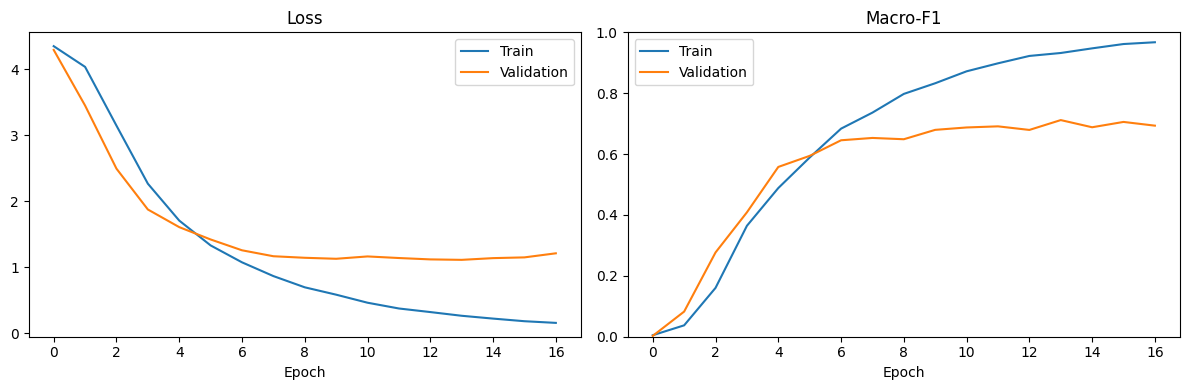

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'model': 'XLM-RoBERTa', 'dataset': '5k_split', 'accuracy': 0.706, 'macro_f1': 0.6998977334677202}


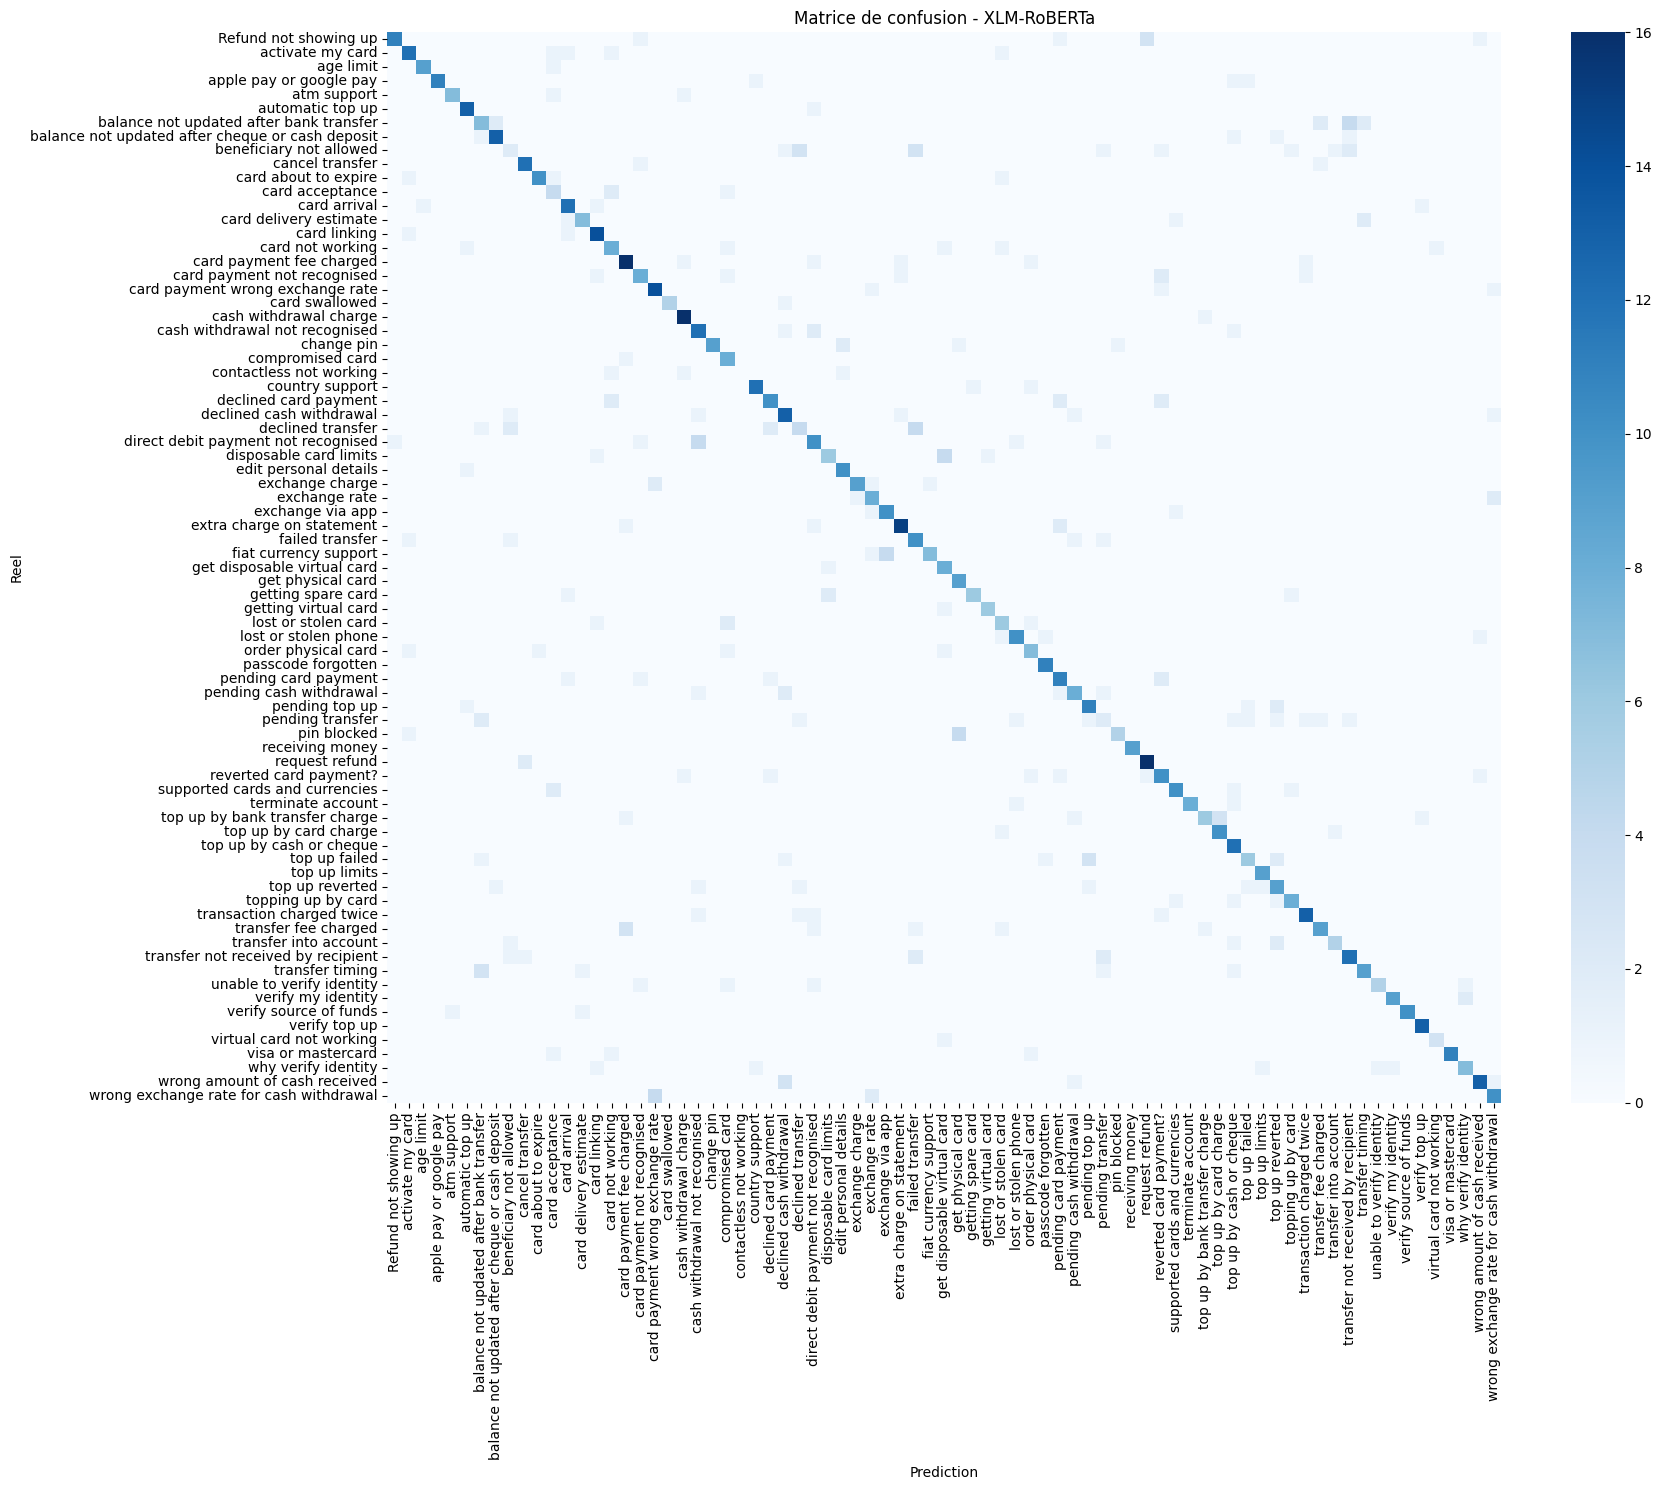

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Validation'); axes[0].set(title='Loss', xlabel='Epoch'); axes[0].legend()
axes[1].plot(history['train_f1'], label='Train'); axes[1].plot(history['val_f1'], label='Validation'); axes[1].set(title='Macro-F1', xlabel='Epoch', ylim=(0, 1)); axes[1].legend()
plt.tight_layout(); plt.savefig(REPORTS_DIR / f'xlmr_history_{DATASET_NAME}.png', dpi=160); plt.show()

transformer_model = AutoModelForSequenceClassification.from_pretrained(transformer_dir).to(device)
transformer_test = run_epoch(transformer_model, test_loader)
transformer_predictions = label_encoder.inverse_transform(transformer_test['predictions'])
transformer_metrics, transformer_report = evaluate_model(test_df['label'], transformer_predictions, 'XLM-RoBERTa', 'transformer')

## 12. Comparaison finale

Le macro-F1 est la mesure principale : il donne le meme poids a chacune des 77 intentions.

,accuracy,macro_f1
model,,
TF-IDF + LinearSVC,74.00%,72.86%
XLM-RoBERTa,70.60%,69.99%


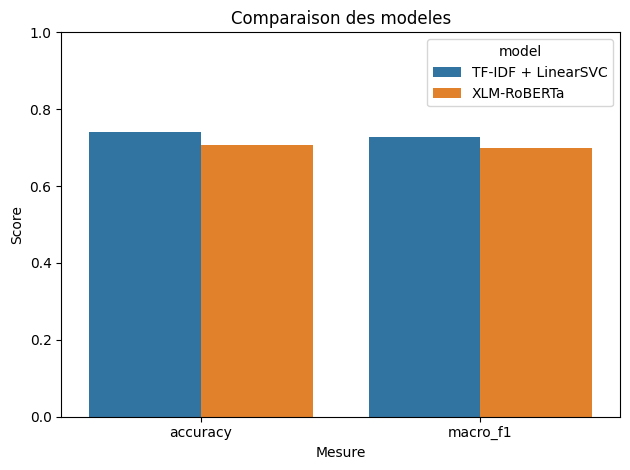

In [12]:
comparison = pd.DataFrame([baseline_metrics, transformer_metrics]).set_index('model')[['accuracy', 'macro_f1']]
display(comparison.style.format('{:.2%}'))
plot_data = comparison.reset_index().melt(id_vars='model', var_name='Mesure', value_name='Score')
sns.barplot(data=plot_data, x='Mesure', y='Score', hue='model')
plt.ylim(0, 1); plt.title('Comparaison des modeles'); plt.tight_layout(); plt.savefig(REPORTS_DIR / f'comparison_{DATASET_NAME}.png', dpi=160); plt.show()

## 12bis. Test statistique global sur le jeu de test

Une difference de macro-F1 entre deux modeles peut venir du hasard de l'echantillon de test (1000 exemples, 77 classes). Cette fonction repond a la question "la difference observee entre baseline et Transformer est-elle statistiquement significative ?" via deux methodes complementaires, calculees sur l'ensemble du jeu de test :

- **Test de McNemar** (test apparié) : compare les erreurs discordantes entre les deux modeles sur les memes exemples de test (ou l'un a raison et l'autre a tort). Adapte car les deux modeles sont evalues sur exactement les memes 1000 exemples.
- **Intervalle de confiance bootstrap (95 %)** sur l'ecart de macro-F1 : ree chantillonne le jeu de test 2000 fois pour estimer la variabilite de l'ecart transformer - baseline. Si l'intervalle ne contient pas 0, l'ecart est considere significatif.

In [13]:
from scipy.stats import binomtest

def statistical_comparison(y_true, preds_a, preds_b, name_a, name_b, n_bootstrap=2000, seed=SEED):
    y_true = np.asarray(y_true)
    preds_a = np.asarray(preds_a)
    preds_b = np.asarray(preds_b)

    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)

    # Test de McNemar (exact, via test binomial sur les cas discordants)
    only_a_correct = int(np.sum(correct_a & ~correct_b))
    only_b_correct = int(np.sum(correct_b & ~correct_a))
    n_discordant = only_a_correct + only_b_correct
    mcnemar_p = binomtest(min(only_a_correct, only_b_correct), n_discordant, p=0.5).pvalue if n_discordant > 0 else 1.0

    # Intervalle de confiance bootstrap sur l'ecart de macro-F1
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f1_a = f1_score(y_true[idx], preds_a[idx], average='macro', zero_division=0)
        f1_b = f1_score(y_true[idx], preds_b[idx], average='macro', zero_division=0)
        diffs[i] = f1_b - f1_a
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])

    print(f"{name_a} correct seul : {only_a_correct} exemples | {name_b} correct seul : {only_b_correct} exemples")
    print(f"Test de McNemar : p-value = {mcnemar_p:.4f}")
    print(f"Bootstrap 95% CI pour (macro-F1 {name_b} - macro-F1 {name_a}) : [{ci_low:.4f}, {ci_high:.4f}]")
    verdict = "significative" if (mcnemar_p < 0.05 or ci_low > 0 or ci_high < 0) else "NON significative"
    print(f"=> Difference {verdict} (seuil p < 0.05 / IC excluant 0).")

    result = {
        'mcnemar_p_value': float(mcnemar_p),
        'bootstrap_ci_macro_f1_diff': (float(ci_low), float(ci_high)),
        f'{name_a}_only_correct': only_a_correct,
        f'{name_b}_only_correct': only_b_correct,
    }
    with open(REPORTS_DIR / f'stat_test_{DATASET_NAME}.json', 'w', encoding='utf-8') as file:
        json.dump(result, file, ensure_ascii=False, indent=2)
    return result

stat_result = statistical_comparison(test_df['label'], baseline_predictions, transformer_predictions, 'baseline', 'transformer')

baseline correct seul : 118 exemples | transformer correct seul : 84 exemples
Test de McNemar : p-value = 0.0200
Bootstrap 95% CI pour (macro-F1 transformer - macro-F1 baseline) : [-0.0582, 0.0010]
=> Difference significative (seuil p < 0.05 / IC excluant 0).


## 13. Fonction `predict_intent`

Utilisez cette fonction pour classer une nouvelle question bancaire en wolof avec le meilleur checkpoint enregistre dans Drive.

In [17]:
def predict_intent(text):
    transformer_model.eval()
    tokens = tokenizer(clean_text(text), truncation=True, max_length=MAX_LENGTH, padding='max_length', return_tensors='pt')
    with torch.no_grad():
        logits = transformer_model(input_ids=tokens['input_ids'].to(device), attention_mask=tokens['attention_mask'].to(device)).logits
    probabilities = torch.softmax(logits, dim=1)[0]
    index = int(probabilities.argmax())
    return {'intention': label_encoder.inverse_transform([index])[0], 'confiance': float(probabilities[index])}

predict_intent('Xamuma lutax ñu bañ sama payoor?  Wax ma lu ko waral, jàppoon naa ni lépp a ngi dox.')

{'intention': 'declined card payment', 'confiance': 0.9610466361045837}